In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
data = pd.read_csv("homeprices.csv")

In [4]:
data.head()

,area,bedrooms,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [5]:
data.isnull().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [12]:
median_value = data['bedrooms'].median()
data['bedrooms'].fillna(median_value, inplace=True)

In [13]:
data.isnull().sum()

area        0
bedrooms    0
age         0
price       0
dtype: int64

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   area      6 non-null      int64  
 1   bedrooms  6 non-null      float64
 2   age       6 non-null      int64  
 3   price     6 non-null      int64  
dtypes: float64(1), int64(3)
memory usage: 320.0 bytes


In [17]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

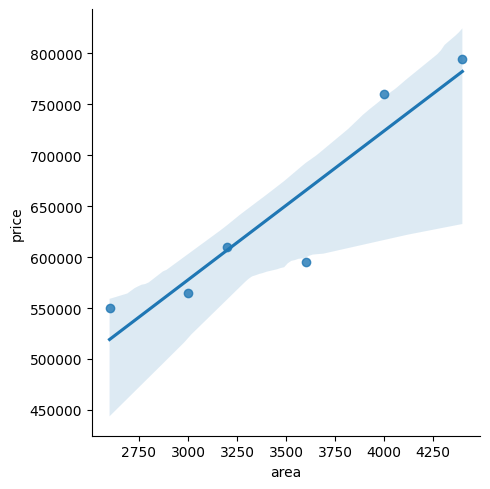

In [18]:
sns.lmplot(x = 'area' , y='price' , data =data)
plt.show()

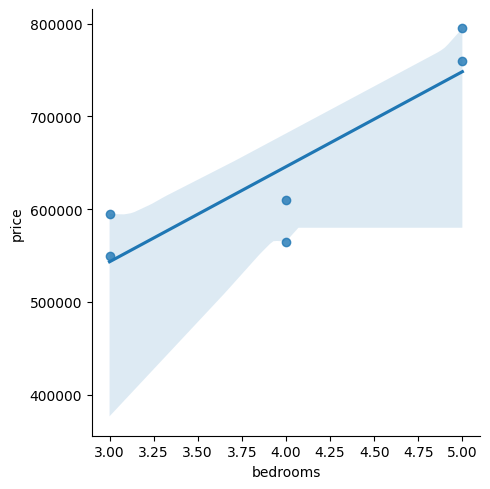

In [19]:
sns.lmplot(x = 'bedrooms' , y='price' , data =data)
plt.show()

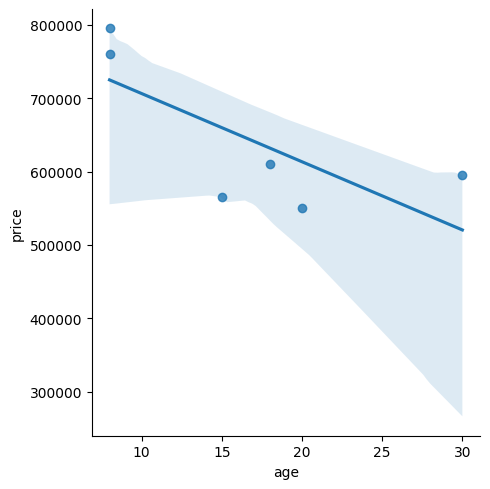

In [20]:
sns.lmplot(x = 'age' , y='price' , data =data)
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [23]:
reg.fit(data[['area' , 'bedrooms' ,'age']] , data['price'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
reg.intercept_

485561.8928233977

In [25]:
reg.coef_

array([   142.895644  , -48591.66405516,  -8529.30115951])

In [26]:
reg.predict([[2000 , 2, 4]])

array([640052.64807263])

In [27]:
import joblib 
joblib.dump(reg , "Hopuseprice_Small_Model.pkl")

['Hopuseprice_Small_Model.pkl']

In [28]:
load = joblib.load('Hopuseprice_Small_Model.pkl')

In [29]:
load.predict([[3000 , 3, 40]])

array([427301.78627387])